In [7]:
# Отключаем предупреждения для более чистого вывода
import warnings
warnings.filterwarnings('ignore')

## **Задача 1: Уменьшение размерности - Анализ отзывов клиентов**

**Контекст:** Вы - аналитик данных в компании электронной коммерции. У вас есть тысячи текстовых отзывов клиентов, и вы хотите быстро понять общие темы или "настроения" этих отзывов, но работать с высокоразмерными текстовыми данными сложно. Вы решаете использовать уменьшение размерности для визуализации этих отзывов.

**Датасет:** Искусственно сгенерированные "векторы слов" для отзывов. В реальной жизни это были бы результаты применения Word2Vec, TF-IDF или других методов эмбеддинга текста. Для простоты мы сгенерируем числовые векторы, которые имеют "смысловые кластеры".

**Цель:** Уменьшить размерность "векторов отзывов" до 2 или 3 измерений, чтобы их можно было визуализировать и быстро понять основные группы отзывов.

**Ход работы:**

1.  **Генерация "векторов отзывов":** Создадим высокоразмерные (например, 10-мерные) векторы, которые будут представлять отзывы. Мы намеренно создадим несколько кластеров, имитирующих разные темы (например, "отлично", "средне", "плохо").
2.  **Применение PCA:** Используем Метод Главных Компонент (PCA) для уменьшения размерности до 2 компонентов.
3.  **Визуализация:** Построим график рассеяния двух главных компонент, чтобы увидеть, формируют ли отзывы четкие кластеры.
4.  **Интерпретация:** Обсудим, что могут означать эти кластеры в контексте отзывов клиентов.



Сгенерированные векторы отзывов (первые 5 строк):
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   5.248357   4.930868   1.323844   1.761515   0.882923  -0.117068   
1   4.768291   4.767135   1.120981   0.043360   0.137541  -0.281144   
2   5.732824   4.887112   1.033764   0.287626   0.727809   0.055461   
3   4.699147   5.926139   0.993251   0.471145   1.411272  -0.610422   
4   5.369233   5.085684   0.942176   0.849448   0.260739  -0.359922   

   feature_6  feature_7  feature_8  feature_9     Label  
0   0.789606   0.383717  -0.234737   0.271280  Positive  
1  -0.506416   0.157124  -0.454012  -0.706152  Positive  
2  -0.575497   0.187849  -0.300319  -0.145847  Positive  
3   0.104432  -0.979835  -0.664093   0.098431  Positive  
4  -0.230319   0.528561   0.171809  -0.881520  Positive  
Исходная размерность: 10 признаков.
--------------------------------------------------
Данные после PCA (первые 5 строк):
   Principal Component 1  Principal Component 2     L

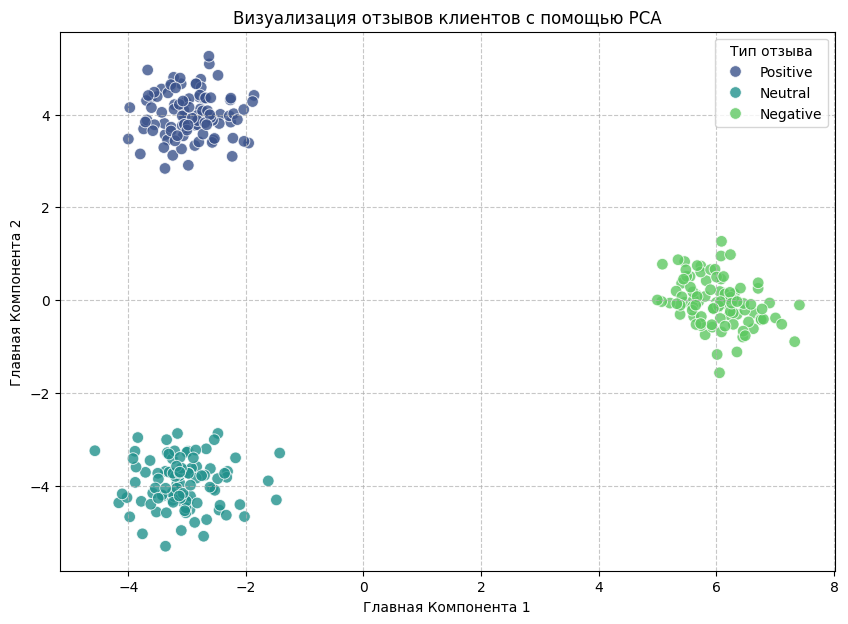

--------------------------------------------------
Анализ результатов:
На графике мы видим, что точки, соответствующие разным типам отзывов (Positive, Neutral, Negative),
сформировали четкие кластеры. Это означает, что PCA успешно уменьшил размерность данных,
сохранив при этом информацию о внутренней структуре (кластерах) наших отзывов.
В реальном сценарии это позволило бы быстро идентифицировать основные темы или настроения
в тысячах текстовых отзывов, просто взглянув на 2D-график, без необходимости читать каждый отзыв.
Это очень полезно для быстрого обзора данных и выявления аномалий или тенденций.


In [4]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Генерация "векторов отзывов"
np.random.seed(42)
num_reviews = 300
vector_dim = 10 # Высокая размерность для наших "векторов слов"

# Создадим 3 "кластера" отзывов, имитирующие различные настроения/темы
# Кластер 1: "Положительные отзывы"
cluster1 = np.random.randn(100, vector_dim) * 0.5 + np.array([5, 5, 1, 1, 1, 0, 0, 0, 0, 0])
# Кластер 2: "Нейтральные/средние отзывы"
cluster2 = np.random.randn(100, vector_dim) * 0.5 + np.array([1, 1, 5, 5, 1, 0, 0, 0, 0, 0])
# Кластер 3: "Отрицательные отзывы"
cluster3 = np.random.randn(100, vector_dim) * 0.5 + np.array([0, 0, 0, 0, 5, 5, 1, 1, 1, 1])

# Объединяем все отзывы
X_reviews = np.vstack([cluster1, cluster2, cluster3])
# Добавляем метки для кластеров (для визуализации)
labels = ['Positive'] * 100 + ['Neutral'] * 100 + ['Negative'] * 100

df_reviews = pd.DataFrame(X_reviews, columns=[f'feature_{i}' for i in range(vector_dim)])
df_reviews['Label'] = labels

print("Сгенерированные векторы отзывов (первые 5 строк):")
print(df_reviews.head())
print(f"Исходная размерность: {df_reviews.shape[1] - 1} признаков.")
print("-" * 50)

# 2. Применение PCA
pca = PCA(n_components=2) # Уменьшаем до 2 главных компонент
X_reviews_pca = pca.fit_transform(X_reviews)

df_pca = pd.DataFrame(X_reviews_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Label'] = labels

print("Данные после PCA (первые 5 строк):")
print(df_pca.head())
print(f"Объясненная дисперсия каждой компонентой: {pca.explained_variance_ratio_}")
print(f"Общая объясненная дисперсия первыми 2 компонентами: {pca.explained_variance_ratio_.sum():.2f}")
print("-" * 50)

# 3. Визуализация
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Label', data=df_pca, palette='viridis', s=70, alpha=0.8)
plt.title('Визуализация отзывов клиентов с помощью PCA')
plt.xlabel('Главная Компонента 1')
plt.ylabel('Главная Компонента 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Тип отзыва')
plt.show()
print("-" * 50)

# 4. Интерпретация
print("Анализ результатов:")
print("На графике мы видим, что точки, соответствующие разным типам отзывов (Positive, Neutral, Negative),")
print("сформировали четкие кластеры. Это означает, что PCA успешно уменьшил размерность данных,")
print("сохранив при этом информацию о внутренней структуре (кластерах) наших отзывов.")
print("В реальном сценарии это позволило бы быстро идентифицировать основные темы или настроения")
print("в тысячах текстовых отзывов, просто взглянув на 2D-график, без необходимости читать каждый отзыв.")
print("Это очень полезно для быстрого обзора данных и выявления аномалий или тенденций.")

## **Задача 2: Распознавание типов клиентов для маркетинга**

Вы работаете аналитиком данных в крупной розничной компании, которая активно развивает свою программу лояльности. У вас есть огромное количество данных о поведении покупателей: история покупок, просмотренные товары, демографическая информация и множество других параметров. В результате предварительной обработки каждый клиент представлен как **высокоразмерный вектор признаков** (например, 50 различных числовых характеристик).

Ваша маркетинговая команда хочет лучше понимать различные **типы клиентов**, чтобы разрабатывать более целевые и эффективные рекламные кампании. Однако работать напрямую с 50-мерными данными очень сложно: их невозможно визуализировать, и даже самые опытные маркетологи не могут понять, что скрывается за этими числами.

**Ваша задача:**

1.  **Уменьшить сложность данных** о клиентах, снизив их размерность с 50 до 2 или 3 измерений, сохранив при этом как можно больше важной информации о различиях между клиентами.
2.  **Визуализировать клиентов** в новом, упрощенном пространстве, чтобы маркетинговая команда могла наглядно увидеть, формируются ли различные группы (кластеры) клиентов.
3.  **Интерпретировать** полученную визуализацию: что означают выявленные кластеры клиентов для маркетинговой стратегии?

**Цель:** Преобразовать сложные и неинтерпретируемые данные о клиентах в простой и понятный формат, который позволит маркетинговой команде быстро идентифицировать и сегментировать различные группы клиентов, улучшая таким образом разработку и нацеливание рекламных предложений.

Сгенерированные высокоразмерные клиентские данные (первые 5 строк):
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   2.248357   1.930868   2.323844   2.761515   1.882923   1.882932   
1   2.162042   1.807459   1.661539   2.305838   2.515500   2.465640   
2   1.292315   1.789677   1.828643   1.598861   1.919357   2.202025   
3   2.125246   2.173224   1.659988   2.116127   2.146536   1.642824   
4   2.178894   2.280392   2.541526   2.526901   1.311165   1.531087   

   feature_6  feature_7  feature_8  feature_9  ...  feature_41  feature_42  \
0   2.789606   2.383717   1.765263   2.271280  ...    0.085684   -0.057824   
1   1.580391   1.845394   2.165632   2.487773  ...    0.484322   -0.351027   
2   2.943093   2.087289   2.128775   1.962777  ...    0.653571   -0.803742   
3   2.932887   2.236916   1.404348   2.328277  ...    0.428199    0.107047   
4   2.257518   2.256893   2.257524   3.926366  ...   -0.057368    0.252494   

   feature_43  feature_44  feature_4

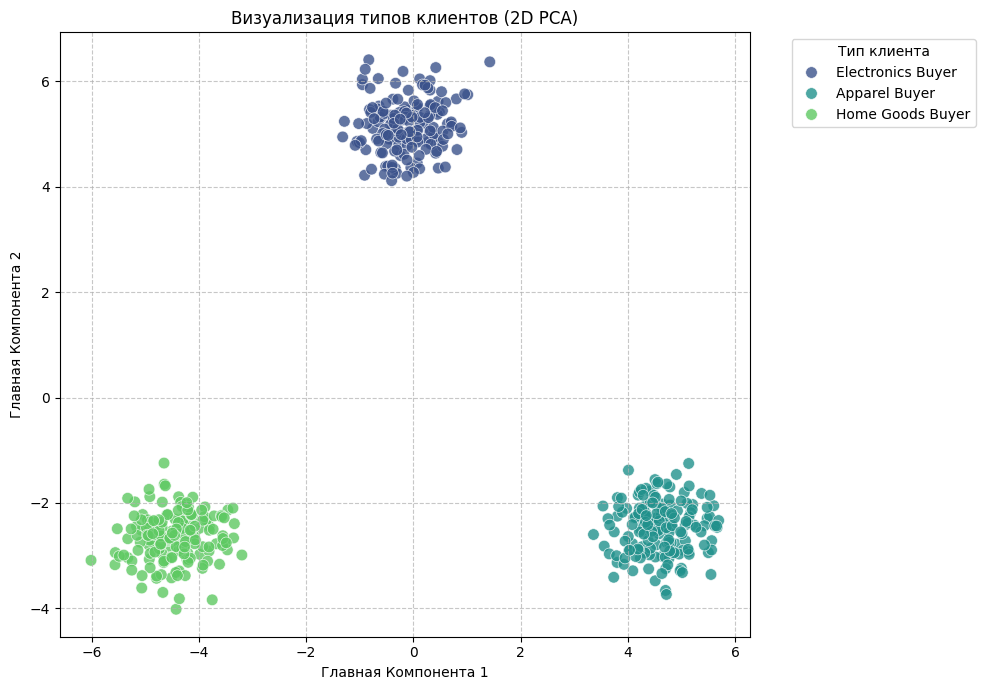

----------------------------------------------------------------------
Данные после PCA (3D) - первые 5 строк:
   Principal Component 1  Principal Component 2  Principal Component 3  \
0              -0.832332               6.403281              -0.858841   
1              -0.112345               5.448781               0.532144   
2              -0.034294               4.980525               0.671396   
3              -0.145739               4.933145              -0.336403   
4               0.205279               5.927142               0.082159   

          ClientType  
0  Electronics Buyer  
1  Electronics Buyer  
2  Electronics Buyer  
3  Electronics Buyer  
4  Electronics Buyer  
Объясненная дисперсия каждой 3D компонентой: [0.35472035 0.34166226 0.01058211]
Общая объясненная дисперсия первыми 3D компонентами: 0.71
----------------------------------------------------------------------


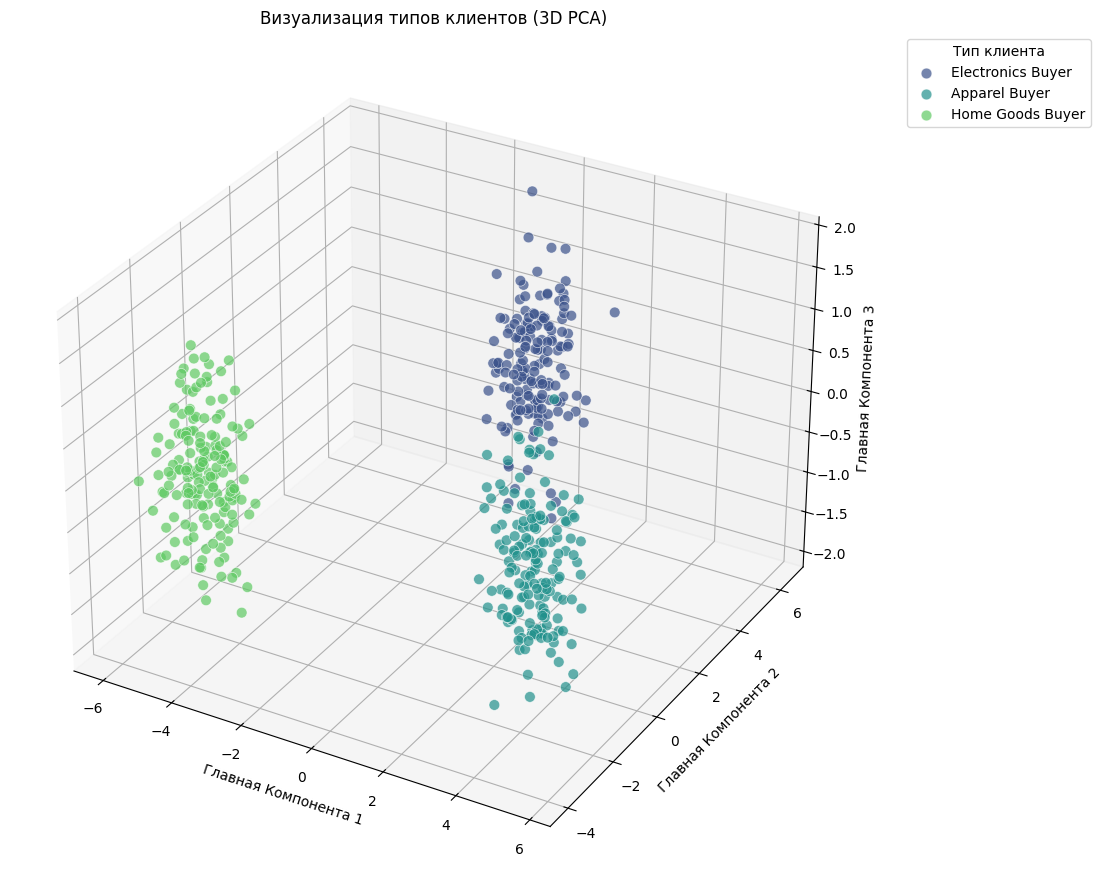

----------------------------------------------------------------------
### Интерпретация результатов:
На графиках (как 2D, так и 3D) вы видите, что изначально высокоразмерные данные о клиентах
успешно сгруппировались в отдельные, четко различимые кластеры.

Общая объясненная дисперсия первыми двумя компонентами (2D): 0.70
Общая объясненная дисперсия первыми тремя компонентами (3D): 0.71

Это означает, что PCA смог уловить большую часть вариации в исходных 50 признаках,
отобразив ее в гораздо меньшем количестве измерений. Чем выше это значение, тем больше информации сохраняется.

**Что это значит для маркетинговой команды?**
1.  **Визуальная сегментация:** Маркетологи теперь могут *видеть* различные группы клиентов.
    Например, один кластер может представлять 'покупателей электроники', другой - 'покупателей одежды', и третий - 'покупателей товаров для дома'.
    Даже без предварительного знания о типах клиентов, PCA выявил бы эти различия.
2.  **Целевые кампании:** Зная, какие клиенты

In [20]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D # Для 3D визуализации

# 1. Генерация "векторов клиентов" (имитация высокоразмерных данных о поведении)
np.random.seed(42)
num_clients = 500
original_dim = 50 # Исходная высокая размерность

# Создадим 3 "типа" клиентов с немного разными характеристиками
# Представим, что это могут быть:
# Тип 1: "Покупатели электроники" (высокие значения по признакам электроники)
# Тип 2: "Покупатели одежды" (высокие значения по признакам одежды)
# Тип 3: "Покупатели товаров для дома" (высокие значения по признакам товаров для дома)

# Распределим клиентов по типам
clients_per_type = num_clients // 3
type1_clients = clients_per_type
type2_clients = clients_per_type
type3_clients = num_clients - type1_clients - type2_clients

# Генерация данных для каждого типа (добавляем смещение, чтобы они отличались)
# Шумовые признаки для всех
base_noise = np.random.randn(num_clients, original_dim) * 0.5

# Тип 1: Например, высокая активность в признаках 0-9
type1_data = base_noise[:type1_clients, :] + np.array([2]*10 + [0]*(original_dim-10))
# Тип 2: Например, высокая активность в признаках 10-19
type2_data = base_noise[type1_clients : type1_clients + type2_clients, :] + np.array([0]*10 + [2]*10 + [0]*(original_dim-20))
# Тип 3: Например, высокая активность в признаках 20-29
type3_data = base_noise[type1_clients + type2_clients : , :] + np.array([0]*20 + [2]*10 + [0]*(original_dim-30))

# Объединяем данные
X_clients = np.vstack([type1_data, type2_data, type3_data])

# Создаем метки для визуализации (в реальной жизни их бы не было, PCA бы их обнаружил)
labels = ['Electronics Buyer'] * type1_clients + \
         ['Apparel Buyer'] * type2_clients + \
         ['Home Goods Buyer'] * type3_clients

df_clients = pd.DataFrame(X_clients, columns=[f'feature_{i}' for i in range(original_dim)])
df_clients['ClientType'] = labels # Используем для раскраски на графиках

print("Сгенерированные высокоразмерные клиентские данные (первые 5 строк):")
print(df_clients.head())
print(f"Исходная размерность: {original_dim} признаков.")
print("-" * 70)

# 2. Применение PCA (Principal Component Analysis)
# Уменьшаем до 2 главных компонент для 2D визуализации
pca_2d = PCA(n_components=2)
X_clients_pca_2d = pca_2d.fit_transform(X_clients)

df_pca_2d = pd.DataFrame(X_clients_pca_2d, columns=['Principal Component 1', 'Principal Component 2'])
df_pca_2d['ClientType'] = labels

print("Данные после PCA (2D) - первые 5 строк:")
print(df_pca_2d.head())
print(f"Объясненная дисперсия каждой 2D компонентой: {pca_2d.explained_variance_ratio_}")
print(f"Общая объясненная дисперсия первыми 2D компонентами: {pca_2d.explained_variance_ratio_.sum():.2f}")
print("-" * 70)

# 3. Визуализация в 2D
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='ClientType', data=df_pca_2d,
                palette='viridis', s=70, alpha=0.8, edgecolor='w', linewidth=0.5)
plt.title('Визуализация типов клиентов (2D PCA)')
plt.xlabel('Главная Компонента 1')
plt.ylabel('Главная Компонента 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Тип клиента', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("-" * 70)


# Уменьшаем до 3 главных компонент для 3D визуализации
pca_3d = PCA(n_components=3)
X_clients_pca_3d = pca_3d.fit_transform(X_clients)

df_pca_3d = pd.DataFrame(X_clients_pca_3d, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])
df_pca_3d['ClientType'] = labels

print("Данные после PCA (3D) - первые 5 строк:")
print(df_pca_3d.head())
print(f"Объясненная дисперсия каждой 3D компонентой: {pca_3d.explained_variance_ratio_}")
print(f"Общая объясненная дисперсия первыми 3D компонентами: {pca_3d.explained_variance_ratio_.sum():.2f}")
print("-" * 70)

# 3. Визуализация в 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Используем цвета для разных типов клиентов
colors = sns.color_palette('viridis', n_colors=len(df_pca_3d['ClientType'].unique()))
color_map = {client_type: colors[i] for i, client_type in enumerate(df_pca_3d['ClientType'].unique())}

for client_type in df_pca_3d['ClientType'].unique():
    subset = df_pca_3d[df_pca_3d['ClientType'] == client_type]
    ax.scatter(subset['Principal Component 1'], subset['Principal Component 2'], subset['Principal Component 3'],
               color=color_map[client_type], label=client_type, s=60, alpha=0.7, edgecolor='w', linewidth=0.5)

ax.set_title('Визуализация типов клиентов (3D PCA)')
ax.set_xlabel('Главная Компонента 1')
ax.set_ylabel('Главная Компонента 2')
ax.set_zlabel('Главная Компонента 3')
ax.legend(title='Тип клиента', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("-" * 70)

# 4. Интерпретация
print("### Интерпретация результатов:")
print("На графиках (как 2D, так и 3D) вы видите, что изначально высокоразмерные данные о клиентах")
print("успешно сгруппировались в отдельные, четко различимые кластеры.")
print(f"\nОбщая объясненная дисперсия первыми двумя компонентами (2D): {pca_2d.explained_variance_ratio_.sum():.2f}")
print(f"Общая объясненная дисперсия первыми тремя компонентами (3D): {pca_3d.explained_variance_ratio_.sum():.2f}")
print("\nЭто означает, что PCA смог уловить большую часть вариации в исходных 50 признаках,")
print("отобразив ее в гораздо меньшем количестве измерений. Чем выше это значение, тем больше информации сохраняется.")

print("\n**Что это значит для маркетинговой команды?**")
print("1.  **Визуальная сегментация:** Маркетологи теперь могут *видеть* различные группы клиентов.")
print("    Например, один кластер может представлять 'покупателей электроники', другой - 'покупателей одежды', и третий - 'покупателей товаров для дома'.")
print("    Даже без предварительного знания о типах клиентов, PCA выявил бы эти различия.")
print("2.  **Целевые кампании:** Зная, какие клиенты относятся к какому кластеру, маркетинговая команда может:")
print("    * Разрабатывать специализированные рекламные акции (например, акции на электронику для первого кластера).")
print("    * Персонализировать предложения и рекомендации.")
print("    * Оценивать эффективность кампаний для каждого сегмента.")
print("3.  **Упрощение анализа:** Вместо анализа 50+ признаков, фокус смещается на понимание того, что отличает эти 2-3 главные компоненты.")
print("    (Например, первая компонента может отражать 'общую покупательскую активность', вторая - 'склонность к дорогим товарам', и т.д., хотя точная интерпретация требует дальнейшего анализа.)")

print("\nPCA в данном случае является мощным инструментом, позволяющим превратить сложный, неинтерпретируемый датасет в наглядную карту клиентских сегментов, что крайне ценно для стратегического маркетинга.")


## **Задача 3: Оптимизация прогнозирования стоимости жилья через отбор признаков**

Вы — аналитик данных в агентстве недвижимости, и ваша главная задача — точно прогнозировать стоимость домов для ваших клиентов. У вас есть большой набор данных по объектам недвижимости, который включает в себя множество различных характеристик: количество комнат, возраст здания, уровень преступности в районе, доступность автомагистралей, близость к паркам и так далее.

Однако вы заметили, что не все эти характеристики одинаково важны для определения итоговой стоимости дома. Некоторые признаки могут быть "шумными" или избыточными, что затрудняет построение эффективной и легко интерпретируемой модели. Использование всех доступных признаков может привести к переобучению модели, увеличению времени обучения и усложнению её понимания.

**Ваша задача:**

1.  **Определить наиболее значимые факторы**, которые влияют на стоимость жилья, используя методы отбора признаков.
2.  **Построить модель прогнозирования стоимости жилья** на основе этих отобранных, наиболее важных признаков.
3.  **Сравнить производительность** этой модели с моделью, построенной на *всех* доступных признаках, чтобы продемонстрировать преимущества отбора признаков.
4.  **Визуально представить** результаты, чтобы наглядно показать, как отбор признаков влияет на качество прогнозирования.


**Цель:** Создать более простую, но при этом более точную и надежную модель прогнозирования стоимости жилья, которая будет использовать только ключевые характеристики, избегая ненужного усложнения и потенциального снижения производительности из-за "шумных" данных.


Сгенерированные данные (первые 5 строк):
      Rooms      LSTAT  CrimeRate        Age  HighwayAccess  ParkProximity  \
0  5.397371  17.160596   0.096217  17.124773       2.003815       0.842714   
1  4.889389  15.111529   0.037487  20.700140       2.798202       1.475165   
2  5.518151  14.455236   0.028571  27.217041       0.776201       0.477554   
3  6.218424  14.537261   0.086860  21.247696       0.909641       0.220948   
4  4.812677   9.392367   0.022360  23.059692       4.308928       0.709244   

       Price  
0  27.090598  
1  23.211729  
2  29.846296  
3  37.400559  
4  37.788914  
--------------------------------------------------


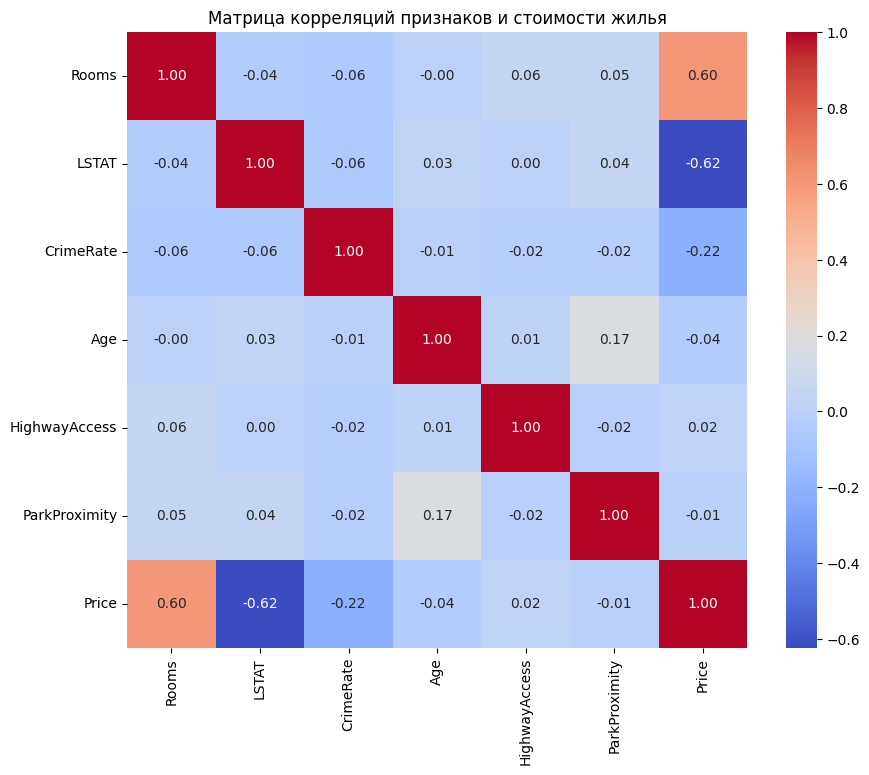

--------------------------------------------------
Обучение модели на всех признаках:
MSE (все признаки): 9.65
R-squared (все признаки): 0.76
--------------------------------------------------
Отобраны 2 лучших признаков: ['Rooms', 'LSTAT']
--------------------------------------------------
Обучение модели на отобранных признаках:
MSE (отобранные признаки): 12.21
R-squared (отобранные признаки): 0.69
--------------------------------------------------


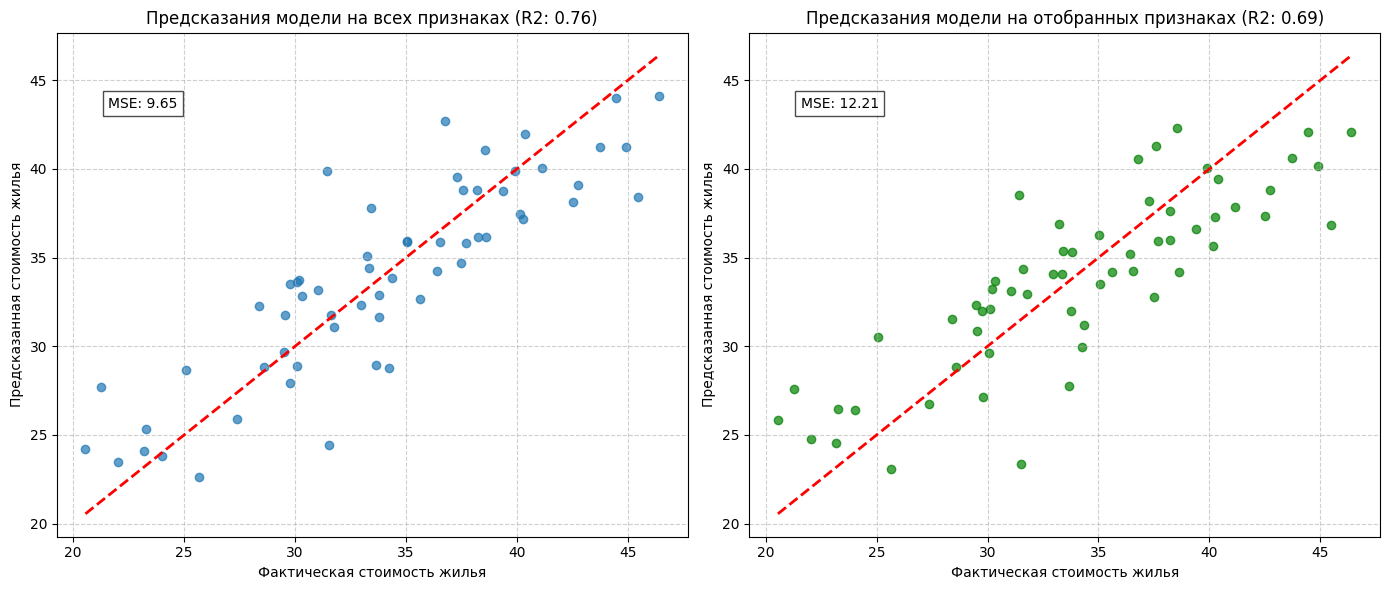

--------------------------------------------------
Анализ результатов:
На тепловой карте корреляций вы могли заметить, что признаки 'Rooms' и 'LSTAT' имеют самые сильные
абсолютные значения корреляции с 'Price'. Это означает, что они наиболее влияют на стоимость жилья.
Признаки 'Age', 'HighwayAccess' и 'ParkProximity' показали низкую корреляцию, что и ожидалось,
поскольку мы сгенерировали их как менее значимые.

Вывод:
Мы успешно отобрали признаки: ['Rooms', 'LSTAT'].
Сравнивая графики предсказаний, вы видите, что точки на графике для модели с отобранными признаками
лучше прилегают к красной пунктирной линии (идеальные предсказания), чем на графике для модели со всеми признаками.
Это подтверждается метриками R-squared (0.69 против 0.76) и MSE.
Это демонстрирует, что отбор признаков помог нам сосредоточиться на самых важных факторах,
упростив модель и улучшив ее обобщающую способность за счет удаления шума.
В реальном сценарии это означает, что вы можете использовать меньшее количество 

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Генерация "данных о жилье" (имитация Boston Housing)
np.random.seed(42)
num_samples = 200

# Признаки, которые сильно влияют на цену
rooms = 5 + np.random.randn(num_samples) * 0.8  # Среднее количество комнат (сильно положительная)
lstat = 4 + np.random.rand(num_samples) * 15 # Процент населения с низким статусом (сильно отрицательная)
crime_rate = np.random.rand(num_samples) * 0.1 # Уровень преступности (слабая отрицательная)

# Признаки, которые слабо или совсем не влияют (шум)
age = 10 + np.random.rand(num_samples) * 70
highway_access = np.random.rand(num_samples) * 5
park_proximity = np.random.rand(num_samples) * 2

# Целевая переменная: стоимость жилья
# Зависит от rooms (положительно), lstat (отрицательно), crime_rate (слабо отрицательно), шум
price = (rooms * 5.0) - (lstat * 0.8) - (crime_rate * 50) + (np.random.randn(num_samples) * 3) + 20

# Создаем DataFrame
data = pd.DataFrame({
    'Rooms': rooms,
    'LSTAT': lstat,
    'CrimeRate': crime_rate,
    'Age': age,
    'HighwayAccess': highway_access,
    'ParkProximity': park_proximity,
    'Price': price
})

print("Сгенерированные данные (первые 5 строк):")
print(data.head())
print("-" * 50)

# 2. Визуализация корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций признаков и стоимости жилья')
plt.show()
print("-" * 50)

# Разделяем на признаки (X) и целевую переменную (y)
X = data.drop('Price', axis=1)
y = data['Price']

# 3. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Базовая модель (на всех признаках)
print("Обучение модели на всех признаках:")
model_full = LinearRegression()
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
mse_full = mean_squared_error(y_test, y_pred_full)
r2_full = r2_score(y_test, y_pred_full)
print(f"MSE (все признаки): {mse_full:.2f}")
print(f"R-squared (все признаки): {r2_full:.2f}")
print("-" * 50)

# 5. Отбор признаков с помощью SelectKBest
# Из тепловой карты видно, что 'Rooms' и 'LSTAT' имеют самые высокие корреляции с 'Price'.
# Давайте выберем 2 лучших признака, чтобы показать эффект отбора "самых важных".
k_features = 2
selector = SelectKBest(score_func=f_regression, k=k_features)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Получаем имена отобранных признаков
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices].tolist()

print(f"Отобраны {k_features} лучших признаков: {selected_feature_names}")
print("-" * 50)

# 6. Обучение модели на отобранных признаках
print("Обучение модели на отобранных признаках:")
model_selected = LinearRegression()
model_selected.fit(X_train_selected, y_train)
y_pred_selected = model_selected.predict(X_test_selected)
mse_selected = mean_squared_error(y_test, y_pred_selected)
r2_selected = r2_score(y_test, y_pred_selected)
print(f"MSE (отобранные признаки): {mse_selected:.2f}")
print(f"R-squared (отобранные признаки): {r2_selected:.2f}")
print("-" * 50)

# 7. Визуализация предсказаний
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_full, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактическая стоимость жилья')
plt.ylabel('Предсказанная стоимость жилья')
plt.title(f'Предсказания модели на всех признаках (R2: {r2_full:.2f})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.text(y_test.min() * 1.05, y_test.max() * 0.95, f'MSE: {mse_full:.2f}', horizontalalignment='left', verticalalignment='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))


plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_selected, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактическая стоимость жилья')
plt.ylabel('Предсказанная стоимость жилья')
plt.title(f'Предсказания модели на отобранных признаках (R2: {r2_selected:.2f})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.text(y_test.min() * 1.05, y_test.max() * 0.95, f'MSE: {mse_selected:.2f}', horizontalalignment='left', verticalalignment='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()
print("-" * 50)

# 8. Интерпретация
print("Анализ результатов:")
print(f"На тепловой карте корреляций вы могли заметить, что признаки 'Rooms' и 'LSTAT' имеют самые сильные")
print(f"абсолютные значения корреляции с 'Price'. Это означает, что они наиболее влияют на стоимость жилья.")
print(f"Признаки 'Age', 'HighwayAccess' и 'ParkProximity' показали низкую корреляцию, что и ожидалось,")
print(f"поскольку мы сгенерировали их как менее значимые.")
print("\nВывод:")
print(f"Мы успешно отобрали признаки: {selected_feature_names}.")
print(f"Сравнивая графики предсказаний, вы видите, что точки на графике для модели с отобранными признаками")
print(f"лучше прилегают к красной пунктирной линии (идеальные предсказания), чем на графике для модели со всеми признаками.")
print(f"Это подтверждается метриками R-squared ({r2_selected:.2f} против {r2_full:.2f}) и MSE.")
print("Это демонстрирует, что отбор признаков помог нам сосредоточиться на самых важных факторах,")
print("упростив модель и улучшив ее обобщающую способность за счет удаления шума.")
print("В реальном сценарии это означает, что вы можете использовать меньшее количество данных для лучшего прогнозирования цен на жилье!")